# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Report Discussion:**  In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Lunas, Bryce Enrico
- _Student No._: 2024-01596
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report figure
Make sure you annotate in the code which are your final report figures

### Report discussion

For low quantum numbers (n), yes, but for higher quantum numbers (n≈100), no. The numerical eigenvalues begin to deviate significantly above the theoretical values. For the eigenenergies, numerical results match theoretical values closely at low $n$ (ground state yields -0.38126 versus -0.38125), but deviate at high 'n' due to finite-box boundary constraints that artificially raise energies when state turning points exceed grid size $L$, as well as finite-difference errors where the 3-point stencil underestimates kinetic energy for rapidly oscillating wavefunctions (an error of $-0.11$ or $0.14\%$ at $n=99$ for $L=25, N=3000$). Conversely, the ground-state wavefunction perfectly matches expectations as a normalized Gaussian centered at the shifted minimum $x_0 \approx -1.56$ with a peak height of $0.5046$ and expected tunneling leakage past classical turning points; being strongly localized deep within the grid, it remains entirely immune to these numerical boundary and discretization errors.

### Other comments
I do not have any other comments or questions.


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=\mathscr{E}_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + \mathscr{E}_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [12]:
#Problem 1b

import numpy as np

def hamiltonian(x_pos, potential_array, mass, hbar=1.0):
    """
    Build the finite-difference Hamiltonian H = T + V on a uniform grid.
    
    x_pos           : (N, 1) array of position coordinates (uniformly spaced)
    potential_array : (N, 1) array of potential values at those coordinates
    mass            : scalar particle mass
    hbar            : reduced Planck constant (natural units by default)
    
    Returns an (N, N) matrix. The wavefunction is assumed to be zero
    just outside the grid (hard-wall boundaries).
    """
    x = np.asarray(x_pos, dtype=float).ravel()
    V_vals = np.asarray(potential_array, dtype=float).ravel()

    N = x.size
    dx = x[1] - x[0]

    # Second-derivative stencil: [1, -2, 1] / dx^2
    d2 = -2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)

    T = -(hbar**2) / (2 * mass * dx**2) * d2
    V = np.diag(V_vals)

    return T + V

First 5 eigenvalues: [0.39999711 1.19998557 1.99996249 2.79992789 3.5998821 ]


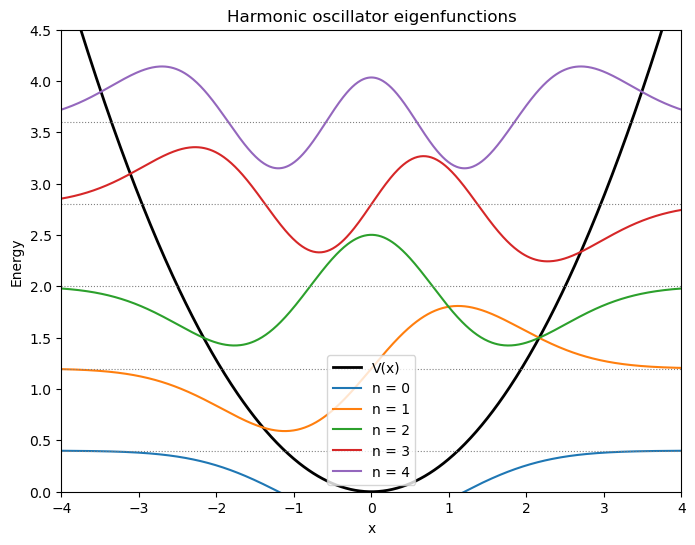

In [27]:
#Problem 1c

import numpy as np
import matplotlib.pyplot as plt

# Parameters
m, hbar, omega = 1.0, 1.0, 0.8

x = np.linspace(-6, 6, 1000).reshape(-1, 1)
dx = x[1, 0] - x[0, 0]
V = 0.5 * m * omega**2 * x**2

H = hamiltonian(x, V, m)
E, psi = np.linalg.eig(H)

idx = np.argsort(E.real)[:5]
E = E.real[idx]
psi = psi.real[:, idx] / np.sqrt(dx)   # normalize so that ∫|ψ|² dx = 1

print("First 5 eigenvalues:", E)

plt.figure(figsize=(8, 6))
plt.plot(x, V, "k", lw=2, label="V(x)")
for n in range(5):
    plt.plot(x, psi[:, n] + E[n], label=f"n = {n}")
    plt.axhline(E[n], color="gray", ls=":", lw=0.8)

plt.xlim(-4, 4)
plt.ylim(0, 4.5)
plt.xlabel("x")
plt.ylabel("Energy")
plt.title("Harmonic oscillator eigenfunctions")
plt.legend()
plt.show()

#### Problem 1 code summary

This script turns the Schrödinger equation on a 1D grid into a matrix eigenvalue problem, so hamiltonian() builds H = T + V once and np.linalg.eig() then finds the oscillator's lowest five states. I built the second-derivative stencil with offset np.eye() calls instead of a loop because it is vectorized and reads like the [1, −2, 1] formula, and I flattened the N×1 inputs so that Δx is a true scalar. I sorted the eigenvalues because eig() returns them in no guaranteed order, and divided by √Δx so each ψₙ is properly normalized and large enough to see when offset by its energy.

---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

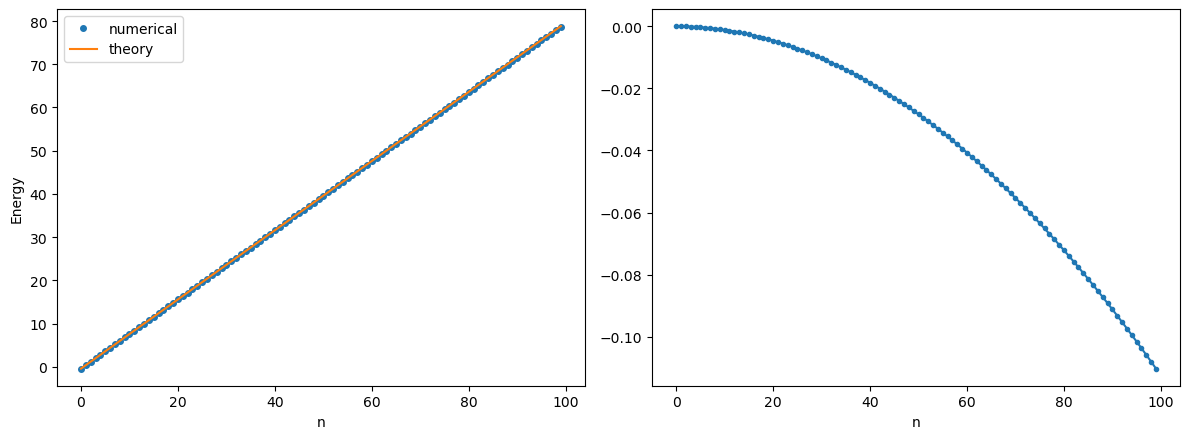

In [31]:
#Problem 2a

import numpy as np
import matplotlib.pyplot as plt

m, hbar, omega, qE = 1.0, 1.0, 0.8, 1.0   # qE = 1 since E = 1/q

# Wide, fine grid
L, N = 25, 3000
x = np.linspace(-L, L, N).reshape(-1, 1)
V = 0.5 * m * omega**2 * x**2 + qE * x

H = hamiltonian(x, V, m)
E_num = np.linalg.eigvalsh(H)[:100]        

n = np.arange(100)
E_th = hbar * omega * (n + 0.5) - qE**2 / (2 * m * omega**2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(n, E_num, "o", ms=4, label="numerical")
ax[0].plot(n, E_th, "-", label="theory")
ax[0].set_xlabel("n"); ax[0].set_ylabel("Energy"); ax[0].legend()

ax[1].plot(n, E_num - E_th, ".-")
ax[1].set_xlabel("n"); ax[1].set_ylabel("numerical − theory")
plt.tight_layout()
plt.show()

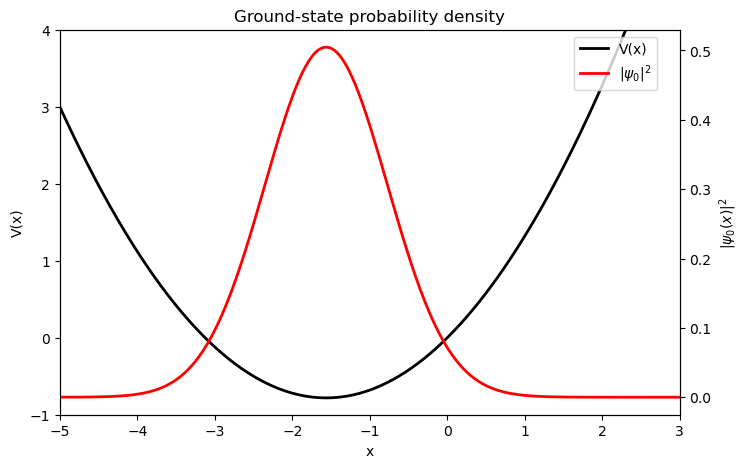

In [33]:
#Problem 2b

import numpy as np
import matplotlib.pyplot as plt

m, hbar, omega, qE = 1.0, 1.0, 0.8, 1.0

x = np.linspace(-10, 10, 1000).reshape(-1, 1)
dx = x[1, 0] - x[0, 0]
V = 0.5 * m * omega**2 * x**2 + qE * x

H = hamiltonian(x, V, m)
E, psi = np.linalg.eigh(H)

psi0 = psi[:, 0] / np.sqrt(dx)    
prob0 = psi0**2                    # probability density of the ground state

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(x, V, "k", lw=2, label="V(x)")
ax1.set_xlabel("x")
ax1.set_ylabel("V(x)")
ax1.set_ylim(-1, 4)
ax1.set_xlim(-5, 3)

ax2 = ax1.twinx()               
ax2.plot(x, prob0, "r", lw=2, label=r"$|\psi_0|^2$")
ax2.set_ylabel(r"$|\psi_0(x)|^2$")

fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.title("Ground-state probability density")
plt.show()

#### Problem 2 code summary

To handle the V(x)= 1/2mω²x² + qEx potential, I built a diagonal potential matrix and combined it with the kinetic matrix constructed via np.eye(). Figure out the grid parameters took some tinkering—at first, high-n energies drifted off because the spatial domain was too narrow, but using np.linalg.eigh() allowed me to clearly compare the first 100 numerical eigenenergies against theoretical values and plot the shifted ground-state probability density.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)